In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from scanpy.experimental.pp import highly_variable_genes


In [3]:
# proteomics_data_train = pd.read_csv(
#     "../0_data/proteins_train_filtered.tsv"
#     , sep="\t"
# )
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [4]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

clinical_data_train[continuous_clinical_columns] = clinical_imputer.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[["mental_status_ambulance"]] = constant_imputer.fit_transform(clinical_data_train[["mental_status_ambulance"]])

clinical_data_train[continuous_clinical_columns] = clinical_scaler.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[['sex']] = sex_scaler.fit_transform(clinical_data_train[['sex']])


In [9]:
def create_organ_dys_labels(clinical_data):

    clinical_data['resp_dysfunction'] =  np.where(
        clinical_data['sofa_resp_day2'] > 0, 1, np.where(
            clinical_data['sofa_resp_day3'] > 0, 1, 0
        )
    )

    clinical_data['renal_dysfunction'] = np.where(
        clinical_data['sofa_renal_day2'] > 0, 1, np.where(
            clinical_data['sofa_renal_day2'] > 0, 1, 0
        )
    )

    clinical_data['cardiovasc_dysfunction'] = np.where(
        clinical_data['sofa_cardiovasc_day2'] > 0, 1, np.where(
            clinical_data['sofa_cardiovasc_day3'] > 0, 1, 0
        )
    )

    clinical_data['coag_dysfunction'] = np.where(
        clinical_data['sofa_coag_day2'] > 0, 1, np.where(
            clinical_data['sofa_coag_day3'] > 0, 1, 0
        )
    )

    clinical_data['cns_dysfunction'] = np.where(
        clinical_data['sofa_cns_day2'] > 0, 1, np.where(
            clinical_data['sofa_cns_day3'] > 0, 1, 0
        )
    )

    clinical_data['liver_dysfunction'] = np.where(
        clinical_data['sofa_liver_day2'] > 0, 1, np.where(
            clinical_data['sofa_liver_day3'] > 0, 1, 0
        )
    )

    return clinical_data

In [10]:
clinical_data_train = create_organ_dys_labels(clinical_data_train)

In [11]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean", bootstrap_iterations=1000)

In [12]:
df_estimator.fit(clinical_data_train, features=clinical_columns)

In [13]:
# proteomics_data_train = pd.read_csv(
#     "../0_data/proteins_train_filtered.tsv"
#     , sep="\t"
# )
clinical_data_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_test['sample'] = clinical_data_test['injection']

In [14]:
clinical_data_test[continuous_clinical_columns] = clinical_imputer.transform(clinical_data_test[continuous_clinical_columns])
clinical_data_test[["mental_status_ambulance"]] = constant_imputer.transform(clinical_data_test[["mental_status_ambulance"]])

clinical_data_test[continuous_clinical_columns] = clinical_scaler.transform(clinical_data_test[continuous_clinical_columns])
clinical_data_test[['sex']] = sex_scaler.transform(clinical_data_test[['sex']])


In [15]:
clinical_data_test['Resp Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="resp_dysfunction", bootstrap=True)

clinical_data_test['Renal Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="renal_dysfunction", bootstrap=True)

clinical_data_test['Cardio Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="cardiovasc_dysfunction", bootstrap=True)

clinical_data_test['Liver Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="liver_dysfunction", bootstrap=True)

clinical_data_test['CNS Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="cns_dysfunction", bootstrap=True)

clinical_data_test['Coag Rate'] = df_estimator.predict(clinical_data_test, features=clinical_columns, target_column="coag_dysfunction", bootstrap=True)

<Axes: >

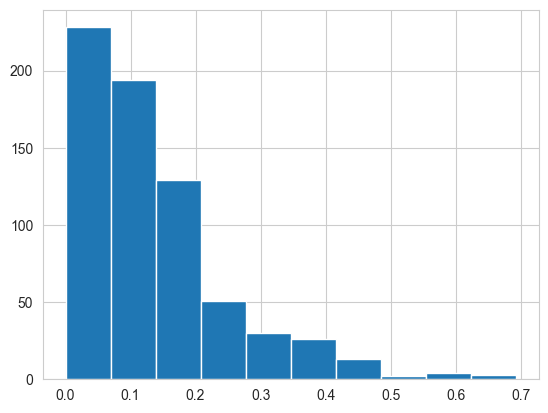

In [23]:
clinical_data_test['Coag Rate'].hist()

In [26]:
clinical_data_test['Liver Rate'].median()

0.0

In [25]:
clinical_data_test[
    clinical_data_test['Liver Rate'] > clinical_data_test['Liver Rate'].median()
]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,sample,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
1,1,SA_BOX_7-267_S4-H8_1_5971,5.827530e-01,-1.107689,2.044809,-1.263782,-1.356894,1.0,-1.060908,0.221389,...,0.0,0.0,0.0,SA_BOX_7-267_S4-H8_1_5971,0.7598,0.5375,0.2965,0.1775,0.0000,0.6316
3,3,SA_BOX_2-1700_S2-D11_1_6971,3.553618e-01,-1.842267,-0.523127,-0.903212,0.000000,1.0,0.011975,0.987296,...,2.0,0.0,0.0,SA_BOX_2-1700_S2-D11_1_6971,0.7296,0.7800,0.2750,0.4205,0.0000,0.3290
5,5,SA_BOX_13-332_S1-H3_1_6519,1.264927e+00,-1.842267,1.174323,-0.903212,-1.228426,1.0,0.597184,-0.652393,...,0.0,NaN,NaN,SA_BOX_13-332_S1-H3_1_6519,0.2096,0.0897,0.3589,0.0001,0.0000,0.3004
6,6,SA_BOX_10-2413_S2-A7_1_6251,-6.678988e-01,-0.128251,-0.653700,-0.542642,0.000000,1.0,0.011975,-0.393495,...,0.0,0.0,0.0,SA_BOX_10-2413_S2-A7_1_6251,0.8196,0.0936,0.0940,0.0032,0.0000,0.0887
11,11,SA_BOX_7-2541_S4-H2_1_5922,6.964486e-01,-0.862829,0.826128,0.719354,0.976951,1.0,-0.475699,-0.717118,...,0.0,0.0,0.0,SA_BOX_7-2541_S4-H2_1_5922,0.4490,0.2966,0.0898,0.0898,0.0599,0.2793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,SA_BOX_12-1949_S5-C4_1_6424,-1.615712e-15,0.606327,0.347360,-0.542642,0.000000,1.0,0.109510,-0.113022,...,2.0,2.0,2.0,SA_BOX_12-1949_S5-C4_1_6424,0.6450,0.3712,0.0909,0.9440,0.0909,0.3917
672,672,SA_BOX_10-1165_S2-B6_1_6243,1.037535e+00,-0.373111,0.347360,-0.182072,0.141905,4.0,-0.768303,-0.868142,...,0.0,NaN,NaN,SA_BOX_10-1165_S2-B6_1_6243,0.4326,0.0035,0.0000,0.0885,0.1013,0.0000
675,675,SA_BOX_6-659_S2-F10_1_5887,-3.268119e-01,-0.373111,-0.914846,-1.444067,-1.549597,1.0,0.011975,0.221389,...,0.0,0.0,0.0,SA_BOX_6-659_S2-F10_1_5887,0.7872,0.3643,0.2684,0.0024,0.0024,0.2716
676,676,SA_BOX_7-2061_S4-H5_1_5946,8.101442e-01,-0.862829,0.956701,-0.650813,0.291785,1.0,0.011975,-0.717118,...,0.0,0.0,0.0,SA_BOX_7-2061_S4-H5_1_5946,0.6011,0.0000,0.1169,0.0898,0.0000,0.0900


In [14]:
clinical_data_train[clinical_data_train['Liver Rate'] > 0]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,cardiovasc_dysfunction,coag_dysfunction,cns_dysfunction,liver_dysfunction,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
2,2,SA_BOX_3-2442_S4-H8_1_5579,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,...,0,0,0,0,0.6,0.1,0.3,0.1,0.0,0.1
11,11,SA_BOX_3-42_S4-F11_1_5601,0.923840,-1.597408,-1.611235,0.647240,0.248962,1.0,-0.865838,0.469499,...,0,0,0,0,1.0,0.5,0.3,0.1,0.1,0.1
17,17,SA_BOX_9-122_S1-G1_1_6110,0.810144,-1.352548,-0.436078,-0.686870,-0.971489,1.0,-0.768303,-0.501369,...,0,0,0,0,0.8,0.1,0.2,0.1,0.0,0.2
18,18,SA_BOX_10-2399_S2-G10_1_6281,-0.781594,-1.842267,-0.349029,-1.624352,0.000000,1.0,0.207045,5.366991,...,1,0,0,0,0.7,0.9,0.4,0.1,0.0,0.2
46,46,SA_BOX_3-1635_S4-D12_1_5607,0.696449,-0.373111,-0.349029,-0.542642,-1.142780,2.0,-0.475699,-0.026722,...,1,0,1,0,0.7,0.3,0.2,0.1,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,651,SA_BOX_1-1651_S1-G3_1_6811,0.696449,-0.862829,-0.305505,0.899639,2.068934,2.0,-1.255977,-0.566094,...,0,1,0,0,0.9,0.2,0.1,0.1,0.0,0.3
653,653,SA_BOX_10-2548_S2-D12_1_6294,0.469057,0.116608,2.610626,-0.686870,-1.014312,2.0,0.011975,-0.145384,...,0,0,0,0,0.8,0.5,0.2,0.1,0.0,0.4
658,658,SA_BOX_8-2543_S5-G2_1_6019,1.037535,-1.107689,1.130798,1.079924,0.000000,1.0,-0.085559,-0.123809,...,0,0,0,0,0.6,0.2,0.2,0.1,0.0,0.0
668,668,SA_BOX_8-1834_S5-H2_1_6020,0.014275,1.096046,0.347360,0.178498,-0.072209,1.0,0.889789,-0.113022,...,0,1,0,0,0.8,0.2,0.0,0.1,0.0,0.2


In [27]:
clinical_data_test.to_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t",
    index=False
)

In [34]:
clinical_data_test[
    (clinical_data_test['Liver Rate'] > 0.0) & (clinical_data_test['Resp Rate'] < 0.1) & (clinical_data_test['Cardio Rate'] < 0.1) & (clinical_data_test['Coag Rate'] < 0.1) & (clinical_data_test['CNS Rate'] < 0.1) & (clinical_data_test['Renal Rate'] < 0.1)
]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,sample,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
